In [64]:
from typing import Any, Dict, Tuple, List
from itertools import groupby
import numpy as np
from numpy.polynomial.hermite import hermgauss
import matplotlib.pyplot as plt
from scipy.stats import norm

In [65]:
def compute_ttr(backlog: Dict[Tuple[Any, ...], float], *, zero_tol: float = 1e-9, return_open: bool = True) -> Dict[Tuple[Any, Any], List[Dict[str, Any]]]:
    if not backlog:
        return {}

    # Prepare (group, time_tuple, value) triples and sort by (group, time)
    triples = []
    for k, v in backlog.items():
        if len(k) < 3:
            raise ValueError(f"Key {k} must have at least (loc, com, time...).")
        triples.append(((k[0], k[1]), k[2:], float(v)))
    triples.sort(key=lambda x: (x[0], x[1]))  # lexicographic time handles multi-index

    results: Dict[Tuple[Any, Any], List[Dict[str, Any]]] = {}

    for g, grp in groupby(triples, key=lambda x: x[0]):
        episodes: List[Dict[str, Any]] = []
        in_run = False
        start = None
        peak = area = 0.0
        steps = 0

        for _, t, val in grp:
            if val > zero_tol:
                if not in_run:
                    in_run = True
                    start = t
                    peak = val
                    area = val
                    steps = 1
                else:
                    steps += 1
                    area += val
                    if val > peak:
                        peak = val
            elif in_run:
                episodes.append({
                    "start_idx": start,
                    "end_idx": t,                 # first nonpositive period
                    "duration_steps": steps,
                    "peak": peak,
                    "area": area,
                })
                in_run = False

        if in_run and return_open:
            episodes.append({
                "start_idx": start,
                "end_idx": None,                  # not yet recovered
                "duration_steps": steps,
                "peak": peak,
                "area": area,
            })

        results[g] = episodes

    return results

In [66]:
backlog = {
    ('loc1','com1_sold',0,0,0): 0.0,
    ('loc1','com1_sold',0,0,1): 2.0,
    ('loc1','com1_sold',0,0,2): 3.0,
    ('loc1','com1_sold',0,0,3): 0.0,   # recovery here
    ('loc1','com1_sold',0,0,4): 0.0,
    ('loc1','com1_sold',0,0,5): 1.0,   # second disruption
    ('loc1','com1_sold',0,0,6): 0.0,   # recover
    ('loc2','com1_sold',1,2): 0.5,     # open episode (no recovery yet)
}

out = compute_ttr(backlog)
# out[('loc1','com1_sold')] ->
# [
#   {'start_idx': (0,0,1), 'end_idx': (0,0,3), 'duration_steps': 2, 'peak': 3.0, 'area': 5.0},
#   {'start_idx': (0,0,5), 'end_idx': (0,0,6), 'duration_steps': 1, 'peak': 1.0, 'area': 1.0},
# ]
# out[('loc2','com1_sold')] ->
# [
#   {'start_idx': (1,2), 'end_idx': None, 'duration_steps': 1, 'peak': 0.5, 'area': 0.5},
# ]


In [67]:
out

{('loc1',
  'com1_sold'): [{'start_idx': (0, 0, 1),
   'end_idx': (0, 0, 3),
   'duration_steps': 2,
   'peak': 3.0,
   'area': 5.0}, {'start_idx': (0, 0, 5),
   'end_idx': (0, 0, 6),
   'duration_steps': 1,
   'peak': 1.0,
   'area': 1.0}],
 ('loc2',
  'com1_sold'): [{'start_idx': (1, 2),
   'end_idx': None,
   'duration_steps': 1,
   'peak': 0.5,
   'area': 0.5}]}

In [68]:
# def normal_to_discrete_gauss_hermite(mu, sigma, n):
#     z, w = hermgauss(n)
#     nodes = mu + sigma * np.sqrt(2) * z
#     probs = w/np.sqrt(np.pi)
#     return nodes, probs

In [69]:
# points, weights = normal_to_discrete_gauss_hermite(mu=100, sigma=15, n=7)

In [70]:
# points

In [71]:
# weights

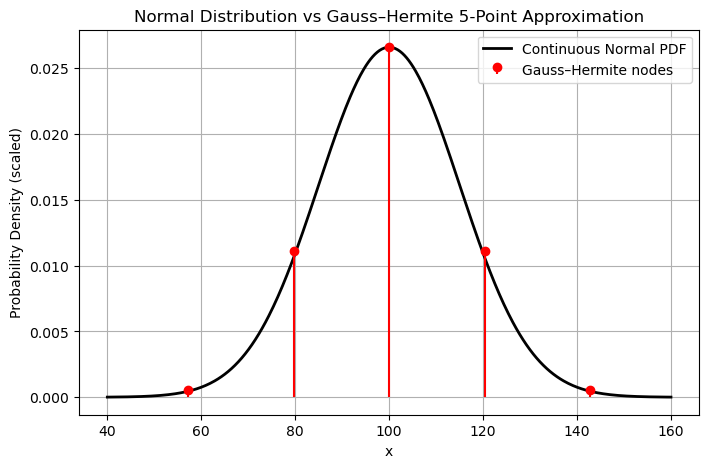

In [82]:
# --- Parameters ---
mu = 100        # mean
sigma = 15     # standard deviation
n = 5         # number of Gauss–Hermite points

# --- Continuous normal PDF ---
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
y = norm.pdf(x, mu, sigma)

# --- Gauss–Hermite approximation ---
z, w = hermgauss(n)
x_nodes = mu + sigma * np.sqrt(2) * z         # transformed nodes
p_nodes = w / np.sqrt(np.pi)                  # normalized weights (sum ≈ 1)

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'k-', lw=2, label='Continuous Normal PDF')

# Scale discrete weights so they’re visually comparable to the density height
scaled_weights = p_nodes * y.max() / p_nodes.max()

plt.stem(x_nodes, scaled_weights, linefmt='r-', markerfmt='ro', basefmt=" ", label='Gauss–Hermite nodes')

plt.title(f'Normal Distribution vs Gauss–Hermite {n}-Point Approximation')
plt.xlabel('x')
plt.ylabel('Probability Density (scaled)')
plt.legend()
plt.grid(True)
plt.show()

# for xi, pi, si in zip(x_nodes, scaled_weights, p_nodes):
#     plt.text(xi, si + 0.01, f"{pi:.3f}", ha='center', fontsize=8)

In [80]:
x_nodes

array([ 57.14544979,  79.6656073 , 100.        , 120.3343927 ,
       142.85455021])

In [79]:
scaled_weights

array([0.00056136, 0.01107408, 0.0265953 , 0.01107408, 0.00056136])